In [1]:
from experiments import UniformMeshes, discretize, continuous_coefficient_2d, continuous_coefficient_3d, ExperimentFactory, Experiment
from dd_solvers import CG, HybridSchwarz, Inv, CUDSS
import numpy as np
import pandas as pd
import torch
import os
import json
import pyamgx
import tqdm
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Every HybridSchwarz instance compiles its own `solve`; avoid falling back to eager.
torch._dynamo.config.cache_size_limit = 64

In [3]:
d = 2
p = 5
mesh_family = UniformMeshes(d=d, m=8)

In [4]:
cg_kwargs = {
    "maxiter": 400,
    "rtol": 1e-9,
}

factory_kwargs = {
    "test_case": continuous_coefficient_2d if d == 2 else continuous_coefficient_3d,
    "polynomial_degree": p,
    "setup_repetitions": 1,
    "solution_warmup_steps": 0,
    "solution_measurement_steps": 1,
    "solution_repetitions": 1,
}

## Selective precision of HybridSchwarz components

`HybridSchwarz(..., precisions={component: dtype})` overrides the precision of individual components; the remaining ones use `preconditioner_precision`:

| component | what it covers |
|---|---|
| `local` | assembly and inversion of the local matrices $A_i$, vectors passed to/from the local solver |
| `coarse` | assembly, factorization (CUDSS) and solves with $A_C$ |
| `R0A_assembly` | summation of rows of $A$ when assembling $R_C A$ |
| `R0A` | storage of $R_C A$ and its SpMV |
| `restriction` | $R_C$ (sums over coarse subdomains) — only in $T_0$ and the initial projection |
| `prolongation` | $R_C^T$ and the update $\mathrm{res} - R_C^T y_C$ |

Additionally `Inv(precision)` controls the storage precision of the local inverses.

Two sweeps: lower one component to f32 on top of an all-f64 preconditioner, and raise one component to f64 on top of an all-f32 preconditioner.

In [5]:
f32, f64 = torch.float32, torch.float64
components = HybridSchwarz.COMPONENTS
projection = ["R0A_assembly", "R0A", "coarse", "prolongation"]


def hybrid(precision, precisions=None, inv_precision=None, **kwargs):
    return CG(
        HybridSchwarz(precision, Inv(inv_precision), CUDSS(), precisions=precisions, **kwargs),
        **cg_kwargs,
    )


# (group, label, solver)
configs = [
    ("reference", "all f64", hybrid(f64)),
    ("reference", "all f32", hybrid(f32)),
    *[("f64, one component in f32", c, hybrid(f64, {c: f32})) for c in components],
    ("f64, one component in f32", "Inv storage", hybrid(f64, inv_precision=f32)),
    *[("f32, components in f64", c, hybrid(f32, {c: f64})) for c in components],
    ("f32, components in f64", ", ".join(projection), hybrid(f32, {c: f64 for c in projection})),
    ("f32, components in f64", "all but local", hybrid(f32, {c: f64 for c in components if c != "local"})),
    ("coarse residual correction", "f64", hybrid(f64, coarse_residual_correction=True)),
    ("coarse residual correction", "f32", hybrid(f32, coarse_residual_correction=True)),
    ("coarse residual correction", "f32, initial_projection", hybrid(f32, coarse_residual_correction=True, initial_projection=True)),
    ("coarse residual correction", "f32, Inv(f16)", hybrid(f32, inv_precision=torch.float16, coarse_residual_correction=True)),
]

In [6]:
factory = ExperimentFactory(**factory_kwargs, mesh_family=mesh_family)

In [7]:
for _, _, solver in configs:
    factory.add(
        Experiment(
            coarse_m="S6",
            solvers_m="S6",
            fine_m="S8",
            solver=solver,
        )
    )

In [8]:
df = factory.run()

Preparing discrete problems:   0%|          | 0/1 [00:00<?, ?it/s]

Preparing discrete problems: 100%|██████████| 1/1 [00:22<00:00, 22.58s/it]

Preparing discrete problems: 100%|██████████| 1/1 [00:22<00:00, 22.58s/it]

Running experiments:   0%|          | 0/21 [00:00<?, ?it/s]

/workspace/src/dd_solvers/dd_solvers/solvers.py:117: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(


...

Running experiments:  86%|████████▌ | 18/21 [01:55<00:18,  6.09s/it]

Running experiments:  90%|█████████ | 19/21 [02:02<00:12,  6.12s/it]

Running experiments:  95%|█████████▌| 20/21 [02:08<00:06,  6.11s/it]

Running experiments: 100%|██████████| 21/21 [02:13<00:00,  6.03s/it]

Running experiments: 100%|██████████| 21/21 [02:13<00:00,  6.38s/it]

In [9]:
residuals = df["metadata"].map(lambda m: np.array(m["residual norms"]) / m["residual norms"][0])
summary = pd.DataFrame({
    "group": [g for g, _, _ in configs],
    "label": [l for _, l, _ in configs],
    "converged": df["exception"].isna(),
    "iterations": df["metadata"].map(lambda m: m["iterations"]),
    "plateau (min rel. residual)": residuals.map(np.min),
    "solver": df["solver"],
})
summary.style.format({"plateau (min rel. residual)": "{:.1e}"}).background_gradient(
    subset=["plateau (min rel. residual)"], cmap="Reds", gmap=np.log10(summary["plateau (min rel. residual)"])
)

,group,label,converged,iterations,plateau (min rel. residual),solver
0,reference,all f64,True,309,3.2e-11,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={}), bsr_matmul=True)"
1,reference,all f32,False,399,3.8e-04,"CG(HybridSchwarz(torch.float32, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={}), bsr_matmul=True)"
2,"f64, one component in f32",local,True,309,3.4e-11,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={local: float32}), bsr_matmul=True)"
3,"f64, one component in f32",coarse,False,399,3.8e-04,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={coarse: float32}), bsr_matmul=True)"
4,"f64, one component in f32",R0A_assembly,False,399,1.3e-06,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={R0A_assembly: float32}), bsr_matmul=True)"
5,"f64, one component in f32",R0A,False,399,3.8e-06,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={R0A: float32}), bsr_matmul=True)"
6,"f64, one component in f32",restriction,False,399,2.3e-09,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={restriction: float32}), bsr_matmul=True)"
7,"f64, one component in f32",prolongation,False,399,4.4e-05,"CG(HybridSchwarz(torch.float64, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={prolongation: float32}), bsr_matmul=True)"
8,"f64, one component in f32",Inv storage,True,309,3.2e-11,"CG(HybridSchwarz(torch.float64, Inv(torch.float32), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={}), bsr_matmul=True)"
9,"f32, components in f64",local,False,399,3.8e-04,"CG(HybridSchwarz(torch.float32, Inv(), CUDSS, initial_projection=False, coarse_residual_correction=False, precisions={local: float64}), bsr_matmul=True)"


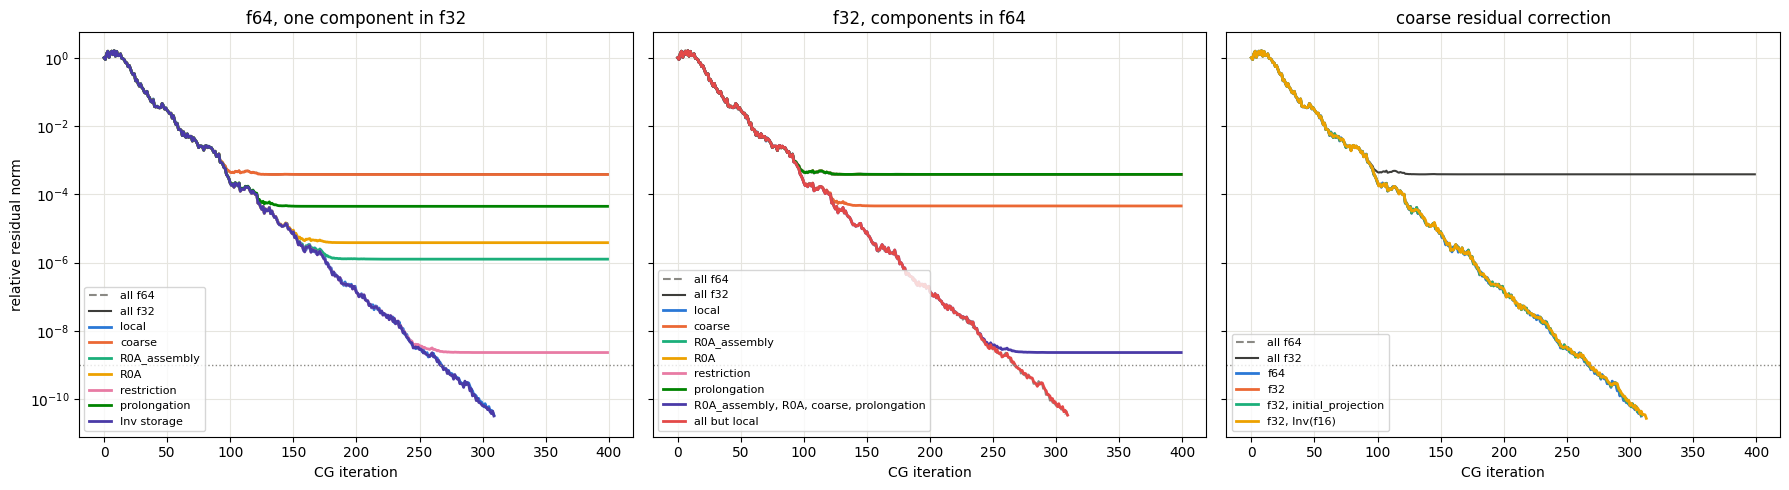

In [10]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
REFERENCE_STYLE = {
    "all f64": dict(color="#8a8984", ls="--", lw=1.5),
    "all f32": dict(color="#3d3d3a", ls="-", lw=1.5),
}
groups = [g for g in dict.fromkeys(summary["group"]) if g != "reference"]

fig, axes = plt.subplots(ncols=len(groups), sharey=True, figsize=(6 * len(groups), 5))
for ax, group in zip(axes, groups):
    for i in summary.index[summary["group"] == "reference"]:
        ax.plot(residuals[i], label=summary.at[i, "label"], **REFERENCE_STYLE[summary.at[i, "label"]])
    for color, i in zip(PALETTE, summary.index[summary["group"] == group]):
        ax.plot(residuals[i], label=summary.at[i, "label"], color=color, lw=2)
    ax.axhline(cg_kwargs["rtol"], color="#8a8984", lw=1, ls=":")
    ax.set_yscale("log")
    ax.set_title(group)
    ax.set_xlabel("CG iteration")
    ax.grid(True, which="major", color="#e6e5df", lw=0.8)
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("relative residual norm")
fig.tight_layout()

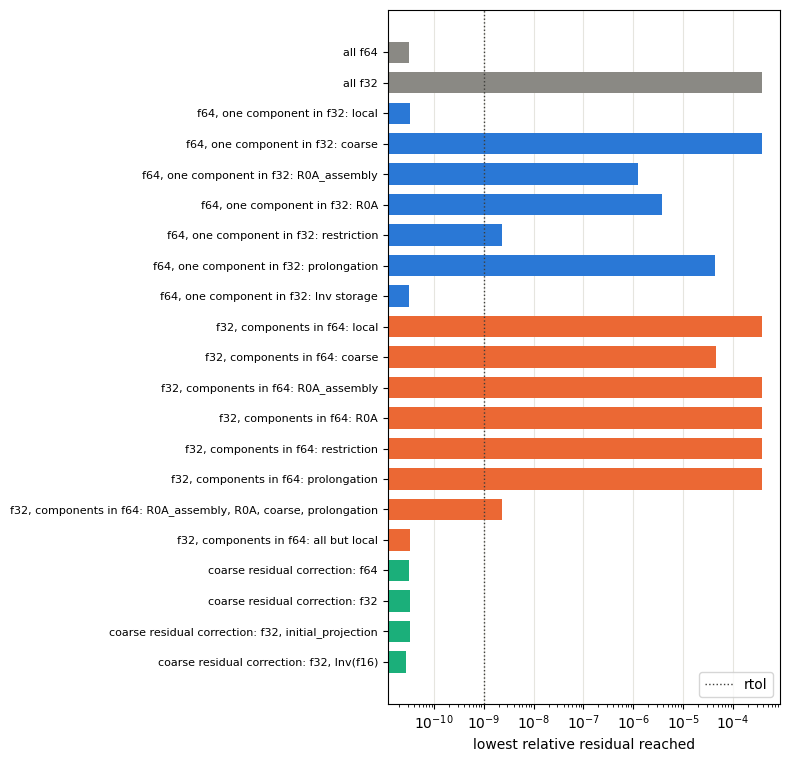

In [11]:
group_colors = {"reference": "#8a8984", **dict(zip(groups, PALETTE))}

fig, ax = plt.subplots(figsize=(8, 0.32 * len(summary) + 1))
y = np.arange(len(summary))[::-1]
ax.barh(y, summary["plateau (min rel. residual)"], color=summary["group"].map(group_colors), height=0.7)
ax.set_yticks(y, [f"{g}: {l}" if g != "reference" else l for g, l in zip(summary["group"], summary["label"])], fontsize=8)
ax.set_xscale("log")
ax.axvline(cg_kwargs["rtol"], color="#3d3d3a", lw=1, ls=":", label="rtol")
ax.set_xlabel("lowest relative residual reached")
ax.grid(True, axis="x", color="#e6e5df", lw=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
fig.tight_layout()

### Interpretation

Without `coarse_residual_correction` the preconditioner is $P^T M^{-1}$ (DEF2; with `initial_projection` it is $P^T M^{-1} P$). Its output is $A$-orthogonal to the coarse space, so $R_C A z = 0$, and the coarse component of the residual $R_C r_k$ is never changed by CG — its value is fixed by $T_0$. In exact arithmetic it is zero; in finite precision every inexact coarse-space operation ($T_0$, $R_C A$, $A_C^{-1}$, $R_C^T$) leaks rounding errors into it, they accumulate and are never removed, so the residual stagnates at the level of $\|R_C r\|$. The local solver does not matter, since the projection is applied after it.

`coarse_residual_correction=True` subtracts $R_C r$ before the coarse solve, giving $P^T M^{-1} + Q$ (A-DEF2; BNN with `initial_projection`), still with a single coarse solve per iteration. Then the coarse residual is reduced at every iteration and rounding errors in the coarse-space operations no longer accumulate.

## Timing: f64 + `Inv(f16)` vs f32 + `Inv(f16)` + `coarse_residual_correction`

Script: `experiments/timing_hybrid_precision.py <d> <p> <fine_m> <coarse_m> <solvers_m> <fine_m>`; raw results (CSV/pickle per case, full tables incl. Additive) in `results/timing_hybrid_precision/`. CG with rtol=1e-9, 1 warm-up solve (torch.compile), min of 5 repetitions; A100 80GB. All configs below converge.

**Measured with the original restriction (`segment_reduce`)** — total CG solve time [ms]:

| case (coarse = solvers) | iters | f64, Inv(f16) | f64, Inv(f16), corr | f32, Inv(f16), corr | f32+corr vs f64 |
|---|---|---|---|---|---|
| 2D p=5 S8, S6 | 311 / 313 | **997** | 1009 | 1017 | +2.0% |
| 2D p=5 S8, S7 | 217 | 543 | 564 | **536** | −1.1% |
| 2D p=5 S8, S8 | 151 | 453 | 490 | **452** | −0.2% |
| 3D p=1 S6, S6 | 41 | 1490 | 1603 | **1415** | −5.0% |
| 3D p=1 S6, S5 | 71 | 432 | 456 | **404** | −6.6% |
| 3D p=2 S5, S5 | 98 | 481 | 516 | **450** | −6.5% |
| 3D p=2 S5, S4 | 140 | 292 | 301 | **281** | −3.8% |
| 3D p=5 S4, S4 | 249 | 872 | 887 | **862** | −1.1% |

Observations:
- The correction does not change iteration counts. f32 + `Inv(f16)` sometimes needs +2 iterations (2D S6).
- f32 gains come almost only from the coarse solve, and CUDSS gains little from f32: −12…−18% of the coarse solve time (e.g. 33.2 → 29.3 ms in 3D p=1 S6). The local solve with `Inv(f16)` is dominated by reading the f16 inverses, so f32 vs f64 vectors barely matter (at 2D S6 f32 is even ~3% slower). Additionally, CG itself (fp64 SpMV, dots) is ~50% of an iteration and is unaffected.
- `Inv(f16)` is always at least as fast as `Inv()` (f32/f64 inverses); keep it.
- Where the coarse space is a noticeable part of the cost (3D), f32 + correction wins by 4–7%; in 2D it is a tie (±2%).

**Correction overhead was mostly `segment_reduce`.** In the original version the correction cost 0.04–0.4 ms per preconditioner application, and 2.7 ms in 3D p=1 S6 (1.5M coarse subdomains). Microbenchmark (`experiments/bench_restrict.py`): `segment_reduce` 2.75 ms vs `index_add_` 0.06 ms for n=6.3M, n_coarse=1.57M; 0.41 vs 0.05 ms for n_coarse=197k. `HybridSchwarz._restrict` now uses `index_add_` (T0 and the correction). After this change only 2D S6 was re-measured (`timing_v2_index_add_partial.log`): the overhead of the correction dropped from +12 ms to +8 ms (1005 vs 997 ms). **The remaining cases were not re-measured**; the expected savings are ~overhead × iterations, e.g. ≈110 ms in 3D p=1 S6 and ≈25 ms in 3D p=1 S5 / p=2 S5, which would make f32 + correction ~10% faster than f64 + `Inv(f16)` in those cases — this is an estimate, to be confirmed by rerunning `timing_hybrid_precision.py`.

Note: `AdditiveSchwarz.solve` still uses `segment_reduce` in every iteration (unchanged, to keep existing results comparable) — it would benefit from the same change.

**Bottom line:** in 2D both options are equivalent; in 3D f32 + `Inv(f16)` + `coarse_residual_correction` is faster (4–7% measured, likely ~10% with the `index_add_` restriction). f64 + `Inv(f16)` remains the simpler and safe choice when the coarse space is small.